prothomaakter937@gmail.com

# Module 05, 06 & 07 Assignment
## Understanding the ML Problem, Exploratory Data Analysis (EDA) and Basic Preprocessing
**Dataset:** Titanic – Machine Learning from Disaster (Kaggle)

Download the **train.csv** file from Kaggle’s Titanic competition and upload it to this notebook. Rename it to `titanic.csv` or update the file name in the loading cell.
Dataset link: https://www.kaggle.com/datasets/yasserh/titanic-dataset

Total Marks: **100**

### Instructions
- This assignment covers:
  - **Module 05:** Basic ML problem framing (features, target, task type).
  - **Module 06:** Exploratory Data Analysis (EDA).
  - **Module 07:** Basic Preprocessing (handling missing values, encoding, scaling).
- Answer all questions inside this notebook using code and markdown.
- Do not delete the original question texts.
- At the end, the notebook should run from top to bottom without errors.

In [25]:
# ==============================
# Setup
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported.")

Libraries imported.


---
## Part 0: Understanding the ML Problem (Module 05) – 10 marks

### 0.1 Load the Dataset and Inspect (5 marks)
**Tasks:**
1. Load `titanic.csv` into a pandas DataFrame.
2. Show `.head()`, `.info()`, and `.describe()`.
3. Briefly look at the column names and data types.


In [26]:
# 0.1 Load the Dataset and Inspect
# TODO: Change file name if needed.
titanic='/content/sample_data/Titanic-Dataset.csv'
df=pd.read_csv(titanic)
# df = pd.read_csv("Titanic-Dataset.csv")#Download the .csv file from Kaggle

print("Shape of dataset:", df.shape)
display(df.head())

print("\nInfo:")
print(df.info())

print("\nDescribe (numeric columns):")
display(df.describe())

Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Describe (numeric columns):


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 0.2 Identify Features, Target and Task Type (5 marks)
**Tasks:**
Based on the dataset:
1. Identify the **target variable** for a predictive model.
2. List at least **5 potential feature columns** you could use.
3. State whether this is a **classification** or **regression** problem, and explain **why**.

Write your answers below.


#### **Your answers**
- Target variable:  Survived
- Feature columns (at least 5):  Pclass, Sex, Age, Fare, Embarked
- Is this classification or regression, and why?:  Classification, because the target (Survived) is a binary categorical variable (0 or 1) rather than a continuous value.

---
## Part A: Exploratory Data Analysis (EDA) – 45 marks

### 1. Initial Exploration and Cleaning Decisions (10 marks)
**Tasks:**
1. Show the number of unique values in each column.
2. Identify columns that are clearly **IDs or high-cardinality text** (for example, `PassengerId`, `Name`, `Ticket`).
3. Decide which of these columns you will **drop** for the rest of the analysis and justify in 2–3 sentences.


In [27]:
# 1. Initial Exploration and Cleaning Decisions (Task 1 is given)
print("Unique values per column:")
for col in df.columns:
    print(col, ":", df[col].nunique())

Unique values per column:
PassengerId : 891
Survived : 2
Pclass : 3
Name : 891
Sex : 2
Age : 88
SibSp : 7
Parch : 7
Ticket : 681
Fare : 248
Cabin : 147
Embarked : 3


#### Columns to drop and justification
- Columns dropped:  PassengerId, Name, Ticket
- Justification (2–3 sentences):  These columns will be dropped because every single row has unique values for them, meaning they offer zero useful patterns for prediction. Leaving them in would just create unnecessary noise and mess up the machine learning model.

---
### 2. Univariate Analysis (15 marks)
**Tasks:**
- Plot histograms for numeric features: `Age`, `Fare`, `SibSp`, `Parch`.
- Plot countplots for categorical features: `Sex`, `Pclass`, `Embarked`.
- Write **two to three insights** about the distributions and any obvious patterns.


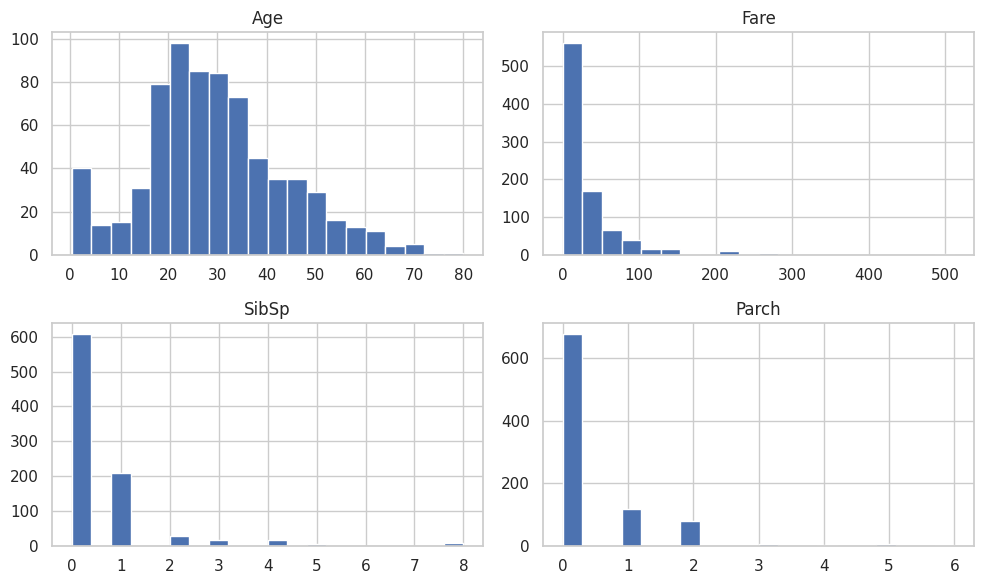


 Plot for categorical features:


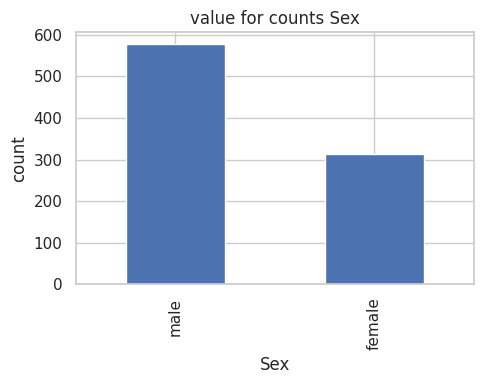

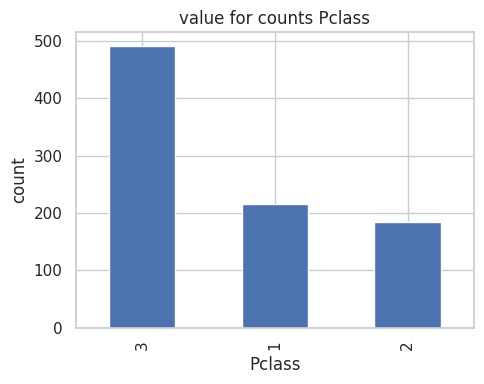

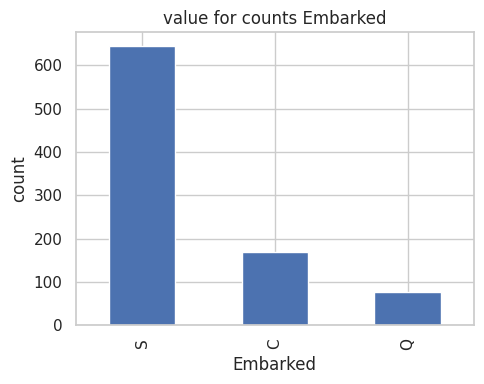

In [29]:
# 2. Univariate Analysis

numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

# Histograms code is written for you
df[numeric_cols].hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()


# Write Countplots code for key categorical variables [You need to complete]
cat_cols = ["Sex", "Pclass", "Embarked"]
print(f'\n Plot for categorical features:')
for c in cat_cols:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind='bar')
  plt.title(f'value for counts {c}')
  plt.ylabel('count')
  plt.tight_layout()
  plt.show()

#### Write Your insights
- Insight 1:  The fare distribution is heavily right-skewed with most passengers paying under 50 and extreme outliers reaching 500+, indicating a need for outlier handling or a log transform.
- Insight 2:  Ages are bell-shaped and centered around 20-30 years old, showing that most passengers were young adults alongside a smaller group of infants and children.
- Insight 3:  Passenger counts show roughly twice as many males as females, with the majority traveling in 3rd class and mostly boarding from Southampton.

---
### 3. Bivariate Analysis with Target (15 marks)
Use `Survived` as the target variable.

**Tasks:**
- Compute and plot a **correlation heatmap** for numeric features, including `Survived`.
- Create a **pairplot** for: `Age`, `Fare`, `SibSp`, `Parch`, and `Survived`.
- Write **two to three insights**, including which variables seem associated with survival.



  Pairplot:


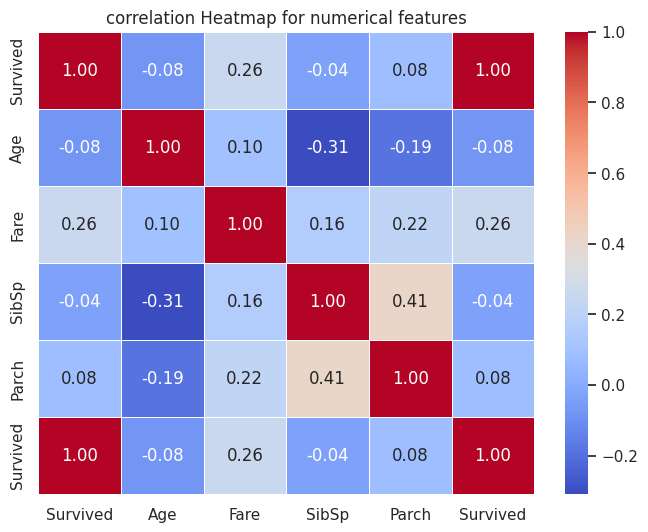

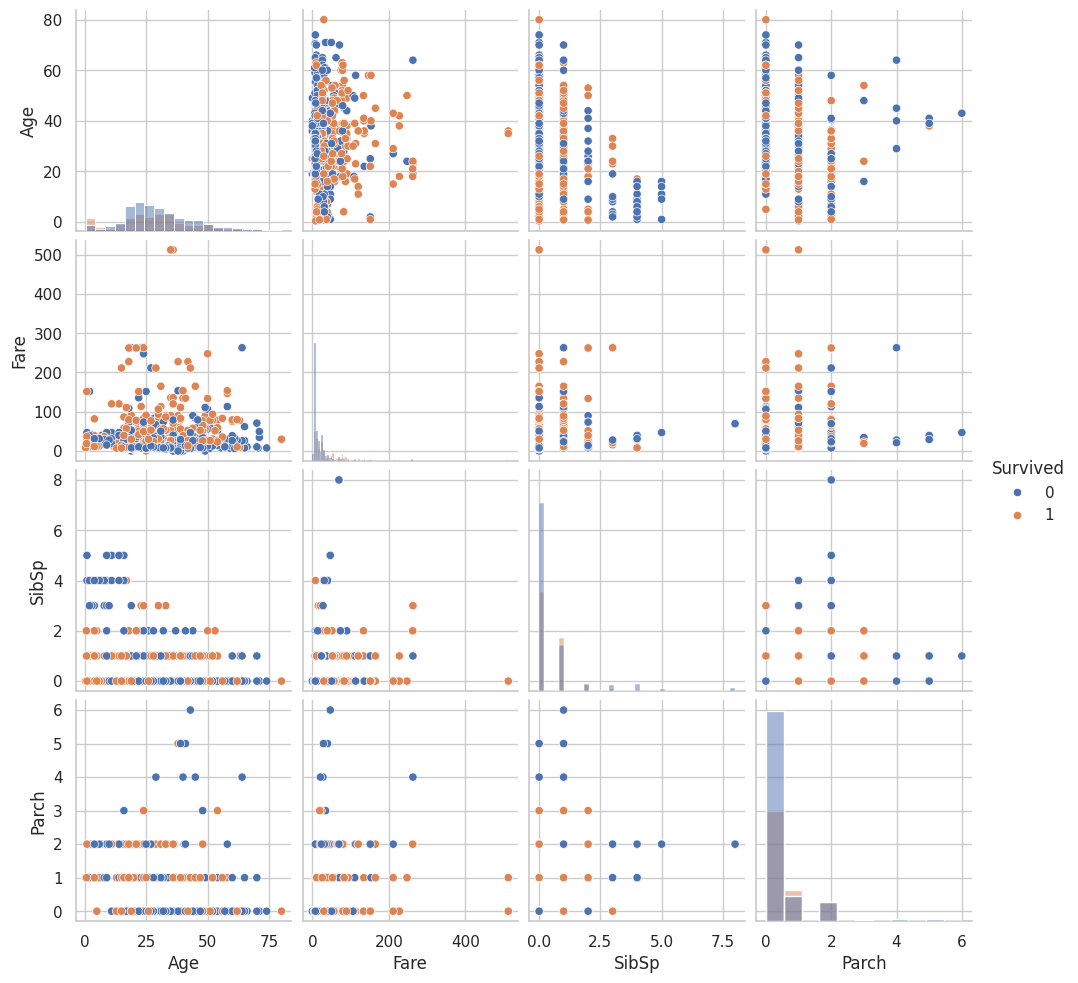

In [30]:
# 3. Bivariate Analysis with Target

num_for_corr = ["Survived", "Age", "Fare", "SibSp", "Parch"]
target_Col='Survived'
## Complete this code block to generate correlation heatmap and pairplot [You need to complete]
corr_matrix=df[num_for_corr +[target_Col]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('correlation Heatmap for numerical features')

print(f'\n  Pairplot:')
sns.pairplot(df[[ "Age", "Fare", "SibSp", "Parch","Survived"]],hue='Survived',diag_kind='hist')
plt.show()

#### Your insights
- Insight 1:  Fare shows a positive correlation with survival because higher fare passengers generally belonged to higher classes with better lifeboat access.
- Insight 2:  Age has a weak direct correlation with survival on its own, though young children experienced slightly better odds.
- Insight 3:  SibSp and Parch display weak individual correlations due to a non linear "sweet spot" where small families outperformed solo travelers and large groups.

---
### 4. Categorical vs Target Analysis (5 marks)
**Tasks:**
For each of the following categorical features: `Sex`, `Pclass`, `Embarked`:
- Plot a **bar chart** showing the proportion of passengers who survived in each category.
- Write **two short insights** about which categories have higher or lower survival chances.



Survival proportion by Sex:


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


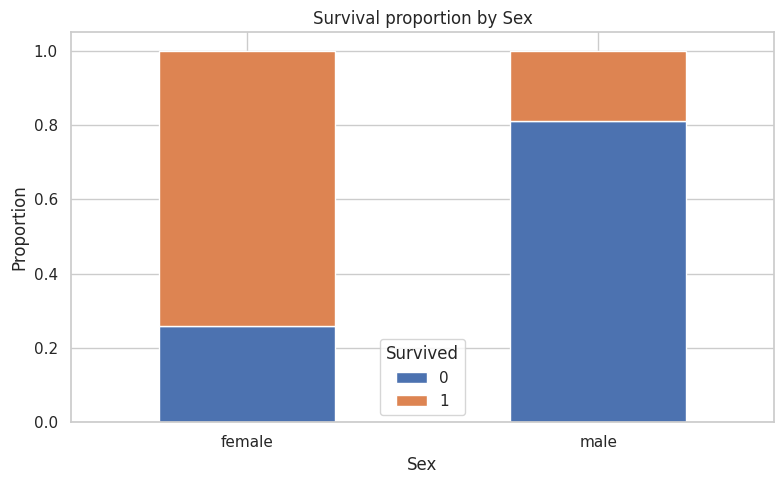


Survival proportion by Pclass:


Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


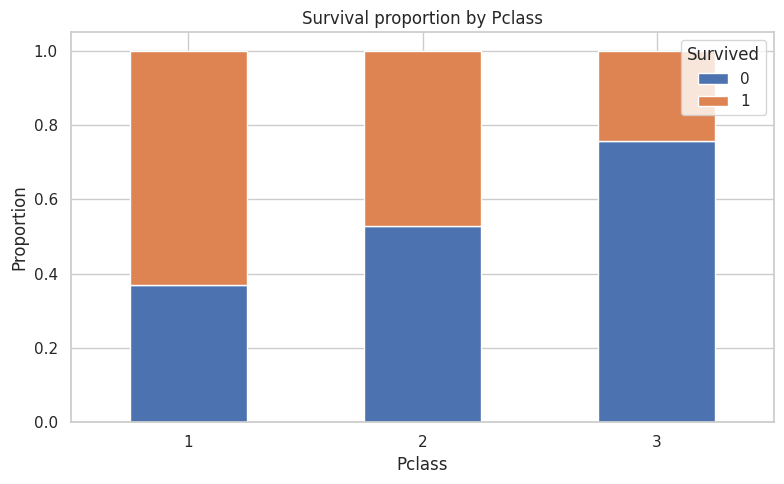


Survival proportion by Embarked:


Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


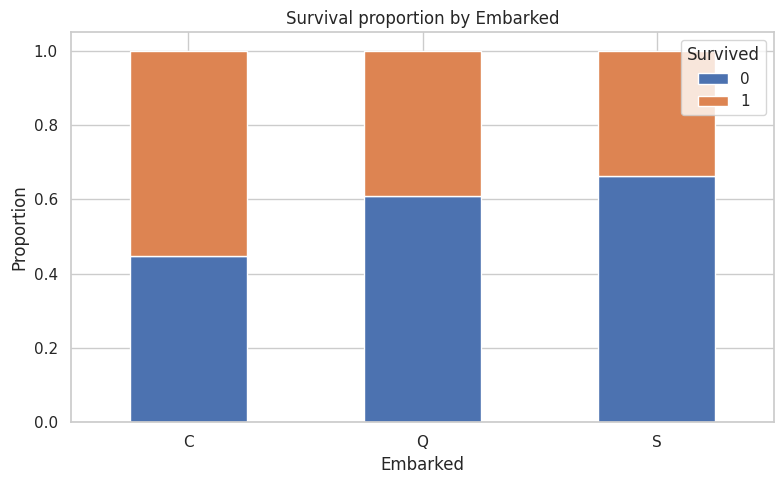

In [31]:
# 4. Categorical vs Target Analysis [Bar chart code is written for you]

cat_target_cols = ["Sex", "Pclass", "Embarked"]

for c in cat_target_cols:
    ct = pd.crosstab(df[c], df["Survived"], normalize="index")
    print(f"\nSurvival proportion by {c}:")
    display(ct)
    ct.plot(kind="bar", stacked=True)
    plt.title(f"Survival proportion by {c}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

#### Your insights
- Insight 1:  Survival depended heavily on sex, with about 74% of female passengers surviving compared to only 19% of males, making it the strongest single-variable pattern.
- Insight 2:  Survival rates dropped sharply by passenger class (63% for 1st, 47% for 2nd, 24% for 3rd) and varied by embarkation port due to underlying class distributions.

---
## Part B: Basic Data Preprocessing – 45 marks

Focus: **Handling missing values, encoding categorical variables, and scaling numeric features.**

### 5. Handling Missing Values (10 marks)
**Tasks:**
1. Show the count of missing values in each column.
2. Decide how to handle missing values for:
   - `Age` (numeric)
   - `Embarked` (categorical)
   - `Cabin` (many missing values)
3. Implement your chosen strategy in code.
4. Show missing value counts again to confirm.
5. Explain your choices in **3–4 sentences**.


In [32]:
# 5. Handling Missing Values

print("Missing values before:") #[Task 1 is done for you]
print(df.isna().sum())

# Drop Cabin (Complete this code block)
df=df.drop(columns=['Cabin'])

# Fill Age (Complete this code block)
age_meidan=df['Age'].median()
df['Age']=df['Age'].fillna(age_meidan)

# Fill Embarked (Complete this code block)
Embarked_mode=df['Embarked'].mode()[0]
df['Embarked']=df['Embarked'].fillna(Embarked_mode)

print("\nMissing values after handling:")
print(df.isna().sum())

Missing values before:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


#### Explanation of your strategy
- Why you dropped or kept `Cabin`:  Cabin was dropped because 687 out of 891 rows were missing, making imputation too risky and likely to introduce noise.
- Why you used median/mean for `Age`:  Age used the median for imputation to handle 177 missing values safely while avoiding sensitivity to outliers.
- Why you used mode or another method for `Embarked`: Embarked used the mode since only 2 values were missing, making it a standard, low-risk fill for categorical data.

---
### 6. Encoding Categorical Variables (15 marks)
Focus on the following categorical features:
- `Sex`
- `Embarked`
- `Pclass` (treat as categorical)

**Tasks:**
- Use `OneHotEncoder` from sklearn to encode these features.
- Keep `Survived` and the main numeric features (`Age`, `Fare`, `SibSp`, `Parch`).
- Show the shape and head of the encoded DataFrame.


In [46]:
# 6. Encoding Categorical Variables
# Select features for encoding and keep important numeric ones
cat_features = ["Sex", "Embarked", "Pclass"]
numeric_features = ["Age", "Fare", "SibSp", "Parch"]
target_col = "Survived"
df_enc = df.copy()
# One hot encode categorical variables [You need to do]
encoded_df = pd.get_dummies(
    df[cat_features],
    columns=cat_features,
    dtype=int
)
# Build final encoded DataFrame
df_model = pd.concat([
    df_enc[[target_col] + numeric_features],
    encoded_df
], axis=1)

print("Shape after encoding:", df_model.shape)
display(df_model.head())

Shape after encoding: (891, 13)


,Survived,Age,Fare,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0,22.0,7.2500,1,0,0,1,0,0,1,0,0,1
1,1,38.0,71.2833,1,0,1,0,1,0,0,1,0,0
2,1,26.0,7.9250,0,0,1,0,0,0,1,0,0,1
3,1,35.0,53.1000,1,0,1,0,0,0,1,1,0,0
4,0,35.0,8.0500,0,0,0,1,0,0,1,0,0,1


---
### 7. Scaling Numeric Features (15 marks)
**Tasks:**
- Use `StandardScaler` on the numeric features: `Age`, `Fare`, `SibSp`, `Parch`.
- Plot boxplots of these features **before** and **after** scaling.
- Write **two sentences** explaining how scaling changes the numeric values and why it is useful before training some ML models.


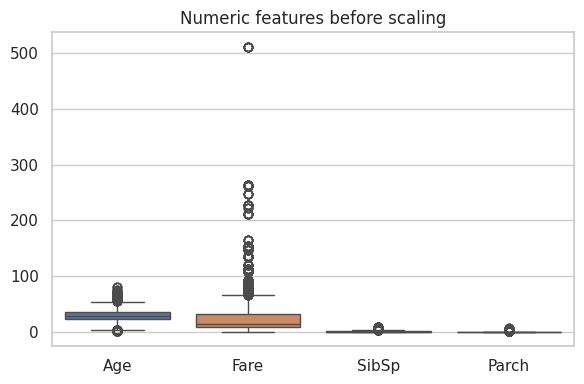


 ---Displayinng standard scaled data--

 ---first 5 rows of x_train---


,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
298,-0.087648,-0.467660,-0.468878,-0.032568,-0.722247,0.722247,-0.460805,-0.308354,0.595793,1.842481,-0.517254,-1.131311
884,-0.318203,-0.467660,-0.468878,-0.487331,-0.722247,0.722247,-0.460805,-0.308354,0.595793,-0.542746,-0.517254,0.883931
247,-0.395055,-0.467660,2.046870,-0.342854,1.384569,-1.384569,-0.460805,-0.308354,0.595793,-0.542746,1.933284,-1.131311
478,-0.548758,-0.467660,-0.468878,-0.478201,-0.722247,0.722247,-0.460805,-0.308354,0.595793,-0.542746,-0.517254,0.883931
305,-2.168793,0.376656,2.046870,2.314937,-0.722247,0.722247,-0.460805,-0.308354,0.595793,1.842481,-0.517254,-1.131311



 ---first 5 rows of x_test---


,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
709,-0.087648,0.376656,0.788996,-0.328391,-0.722247,0.722247,2.170116,-0.308354,-1.678435,-0.542746,-0.517254,0.883931
439,0.142907,-0.467660,-0.468878,-0.420425,-0.722247,0.722247,-0.460805,-0.308354,0.595793,-0.542746,1.933284,-1.131311
840,-0.702462,-0.467660,-0.468878,-0.470362,-0.722247,0.722247,-0.460805,-0.308354,0.595793,-0.542746,-0.517254,0.883931
720,-1.778386,-0.467660,0.788996,0.015914,1.384569,-1.384569,-0.460805,-0.308354,0.595793,-0.542746,1.933284,-1.131311
39,-1.163572,0.376656,-0.468878,-0.406042,1.384569,-1.384569,2.170116,-0.308354,-1.678435,-0.542746,-0.517254,0.883931


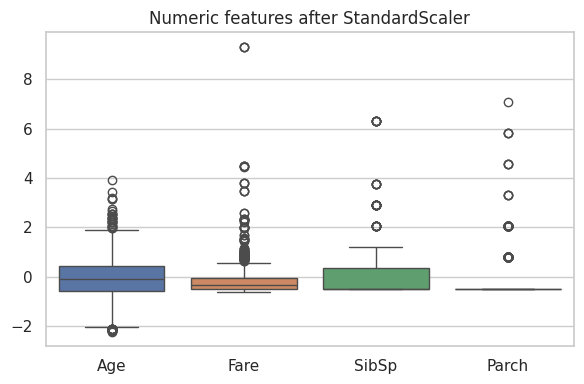

In [34]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 7. Scaling Numeric Features

score_cols = ["Age", "Fare", "SibSp", "Parch"]

# Boxplot before scaling
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_model[score_cols])
plt.title("Numeric features before scaling")
plt.tight_layout()
plt.show()

# Apply StandardScaler [You need to do]
x = encoded_df.drop(columns=[target_Col, 'PassengerId', 'Name', 'Ticket'])
y=encoded_df[target_Col]

x_train,x_test, y_train,y_test=train_test_split(x,y, test_size=.25, random_state=42)

#standard scaling
scaler_sd= StandardScaler()
x_train_std=scaler_sd.fit_transform(x_train)
x_test_std=scaler_sd.transform(x_test)
print('\n ---Displayinng standard scaled data--')

#convet scaled arrays back to dataframse for batte visulalization with colums names
x_train_std_df=pd.DataFrame(x_train_std, columns=x_train.columns, index=x_train.index)
x_test_std_df=pd.DataFrame(x_test_std, columns=x_test.columns, index=x_test.index)
print('\n ---first 5 rows of x_train---')
display(x_train_std_df.head())
print('\n ---first 5 rows of x_test---')
display(x_test_std_df.head())
df_scaled = x_train_std_df

# Boxplot after scaling
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_scaled[score_cols])
plt.title("Numeric features after StandardScaler")
plt.tight_layout()
plt.show()

#### Your observations on scaling
- Sentence 1:  Fare dominates the unscaled boxplot due to its large 0-500 range, making Age, SibSp, and Parch appear flat by comparison on a shared axis.
- Sentence 2:  StandardScaler centers all features around 0 with a standard deviation of 1 for side-by-side comparison, though extreme Fare values remain as outliers measured in standard deviations.

---
### 8. Simple Feature Quality Check (5 marks)
**Tasks:**
- Show `.info()` of the final processed DataFrame (`df_scaled`).
- Confirm there are no missing values.
- Confirm that all remaining features are numeric and suitable for most ML models.
- Write **one short concluding remark** about dataset readiness.


In [35]:
# 8. Simple Feature Quality Check
print(df_scaled.info())

print("\nTotal missing values in final DataFrame:", df_scaled.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 298 to 102
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         668 non-null    float64
 1   SibSp       668 non-null    float64
 2   Parch       668 non-null    float64
 3   Fare        668 non-null    float64
 4   Sex_female  668 non-null    float64
 5   Sex_male    668 non-null    float64
 6   Embarked_C  668 non-null    float64
 7   Embarked_Q  668 non-null    float64
 8   Embarked_S  668 non-null    float64
 9   Pclass_1    668 non-null    float64
 10  Pclass_2    668 non-null    float64
 11  Pclass_3    668 non-null    float64
dtypes: float64(12)
memory usage: 67.8 KB
None

Total missing values in final DataFrame: 0


#### Final remark on dataset readiness
- Your remark:  The dataset is fully numeric with zero missing values across all 12 columns, making it model-ready for algorithms like logistic regression, SVM, and KNN. The check reflects only the training split (668 rows) due to the train-test split, so checking the test set or combined data is needed for a full-dataset verification.

---
## Submission
- Run all cells from top to bottom to make sure everything works.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.